# Chapter 5: Classification

**Book:** Practical Statistics for Data Scientists, Second Edition  
**Authors:** Peter Bruce, Andrew Bruce, and Peter Gedeck

## 1. Introduction to Classification

Classification is a supervised learning method used to predict the category or class of an observation. A model is trained using data with known outcomes and then applied to new observations whose outcomes are unknown.

Classification can be used to solve problems such as detecting fraudulent transactions, predicting customer churn, and identifying spam emails.

Many classification models can also estimate the probability that an observation belongs to a particular class. A probability threshold is then used to determine the final predicted class.

### Objectives
- Understand the basic concept of classification.
- Implement classification algorithms using Python.
- Estimate class probabilities.
- Evaluate classification models using appropriate metrics.
- Understand strategies for handling imbalanced data.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Load dataset for classification
data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Dataset shape:", X.shape)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Target classes:", data.target_names)

Dataset shape: (569, 30)
Training data: (426, 30)
Testing data: (143, 30)
Target classes: ['malignant' 'benign']


## 2. Naive Bayes

Naive Bayes is a classification method based on Bayes' theorem. It calculates the probability of a class given the observed predictor variables.

The method assumes that the predictor variables are conditionally independent given the outcome class. Although this assumption may not always hold in real-world data, Naive Bayes can still be useful because it is simple and computationally efficient.

For numerical predictor variables, Gaussian Naive Bayes assumes that the values within each class follow a normal distribution.

In [5]:
# Train a Naive Bayes classifier
naive_model = GaussianNB()
naive_model.fit(X_train, y_train)

# Predict the test data
nb_pred = naive_model.predict(X_test)
nb_prob = naive_model.predict_proba(X_test)

print("Naive Bayes Accuracy:",
      accuracy_score(y_test, nb_pred))

print("\nClassification Report:")
print(classification_report(
    y_test, nb_pred,
    target_names=data.target_names
))

print("First five predicted probabilities:")
print(nb_prob[:5])

Naive Bayes Accuracy: 0.9370629370629371

Classification Report:
              precision    recall  f1-score   support

   malignant       0.96      0.87      0.91        53
      benign       0.93      0.98      0.95        90

    accuracy                           0.94       143
   macro avg       0.94      0.92      0.93       143
weighted avg       0.94      0.94      0.94       143

First five predicted probabilities:
[[1.97394768e-11 1.00000000e+00]
 [1.00000000e+00 4.38811379e-24]
 [1.36488826e-04 9.99863511e-01]
 [5.54038120e-07 9.99999446e-01]
 [5.26993645e-05 9.99947301e-01]]


## 3. Discriminant Analysis

Discriminant analysis is a statistical classification technique that separates observations into different classes. Linear Discriminant Analysis (LDA) uses the distributions of predictor variables within each class to determine a decision boundary.

LDA assumes that the classes share a common covariance matrix. It can be used to classify new observations, estimate class probabilities, and understand how predictor variables contribute to class separation.

In [6]:
# Train a Linear Discriminant Analysis model
lda_model = make_pipeline(
    StandardScaler(),
    LinearDiscriminantAnalysis()
)

lda_model.fit(X_train, y_train)

# Generate predictions
lda_pred = lda_model.predict(X_test)
lda_prob = lda_model.predict_proba(X_test)[:, 1]

print("LDA Accuracy:",
      accuracy_score(y_test, lda_pred))

print("LDA ROC AUC:",
      roc_auc_score(y_test, lda_prob))

print("\nClassification Report:")
print(classification_report(
    y_test, lda_pred,
    target_names=data.target_names
))

LDA Accuracy: 0.951048951048951
LDA ROC AUC: 0.9943396226415094

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.89      0.93        53
      benign       0.94      0.99      0.96        90

    accuracy                           0.95       143
   macro avg       0.96      0.94      0.95       143
weighted avg       0.95      0.95      0.95       143



## 4. Logistic Regression

Logistic regression is a classification method that estimates the probability of an outcome. It is particularly useful for binary classification problems.

The model uses a logistic function to ensure that predicted probabilities range from 0 to 1. The logit function transforms a probability into log-odds, allowing the relationship between predictors and the outcome to be represented using a linear expression.

Predicted probabilities can be converted into class labels using a selected threshold. A threshold of 0.5 is common, although other thresholds may be more suitable depending on the problem.

In [7]:
# Create and train the logistic regression model
logit_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42)
)

logit_model.fit(X_train, y_train)

# Predict class labels and probabilities
logit_pred = logit_model.predict(X_test)
logit_prob = logit_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, logit_pred))

print("Logistic Regression ROC AUC:",
      roc_auc_score(y_test, logit_prob))

print("\nClassification Report:")
print(classification_report(
    y_test, logit_pred,
    target_names=data.target_names
))

Logistic Regression Accuracy: 0.986013986013986
Logistic Regression ROC AUC: 0.9976939203354298

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



## 5. Evaluating Classification Models

Classification models need to be evaluated using appropriate performance metrics.

- **Accuracy:** the proportion of all predictions that are correct.
- **Confusion Matrix:** summarizes correct and incorrect predictions by class.
- **Precision:** the proportion of predicted positive cases that are actually positive.
- **Recall:** the proportion of actual positive cases correctly identified.
- **Specificity:** the proportion of actual negative cases correctly identified.
- **ROC Curve:** illustrates the relationship between the true positive rate and the false positive rate at different thresholds.
- **AUC:** summarizes the model's ability to distinguish between classes. A value closer to 1 generally indicates better discrimination.

Confusion Matrix:
[[52  1]
 [ 1 89]]

Detailed Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



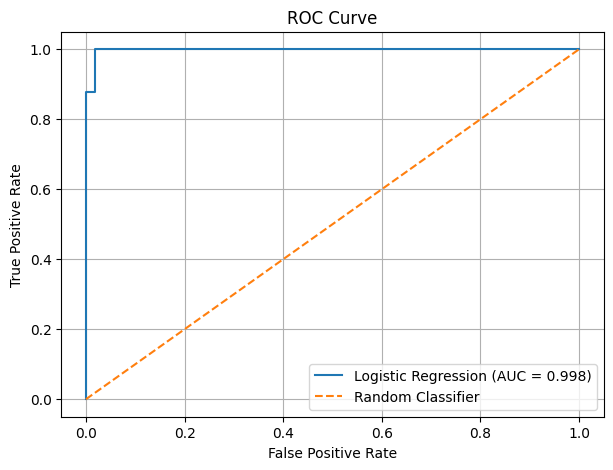

In [8]:
# Evaluate the logistic regression model
cm = confusion_matrix(y_test, logit_pred)

print("Confusion Matrix:")
print(cm)

print("\nDetailed Classification Report:")
print(classification_report(
    y_test, logit_pred,
    target_names=data.target_names
))

# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, logit_prob)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr, tpr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, logit_prob):.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

## 6. Strategies for Imbalanced Data

Imbalanced data occurs when one class contains significantly more observations than another. In this situation, accuracy alone may not provide a reliable evaluation of model performance.

Several strategies can be used to address imbalanced data:

- **Undersampling:** reduces the number of observations from the majority class.
- **Oversampling:** increases the representation of the minority class.
- **Class weighting:** assigns different weights to classes during model training.
- **Data generation:** creates synthetic observations to improve minority-class representation.
- **Cost-based classification:** considers the different costs of false positive and false negative predictions.

These strategies should be applied carefully. Resampling must be performed only on training data to avoid data leakage.

### Summary

Classification is a supervised learning technique used to predict categorical outcomes. Naive Bayes uses probability theory, discriminant analysis separates classes using their statistical distributions, and logistic regression estimates class probabilities.

Classification models should be evaluated using several metrics, including the confusion matrix, precision, recall, specificity, ROC curve, and AUC. When the classes are imbalanced, the choice of threshold and the cost of classification errors become especially important.

In [9]:
# Compare different probability thresholds
threshold_values = [0.3, 0.5, 0.7]

for threshold in threshold_values:
    threshold_pred = (logit_prob >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print("Accuracy:",
          round(accuracy_score(y_test, threshold_pred), 4))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, threshold_pred))
    print(classification_report(
        y_test,
        threshold_pred,
        target_names=data.target_names,
        zero_division=0
    ))


Threshold: 0.3
Accuracy: 0.979
Confusion Matrix:
[[50  3]
 [ 0 90]]
              precision    recall  f1-score   support

   malignant       1.00      0.94      0.97        53
      benign       0.97      1.00      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.97      0.98       143
weighted avg       0.98      0.98      0.98       143


Threshold: 0.5
Accuracy: 0.986
Confusion Matrix:
[[52  1]
 [ 1 89]]
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143


Threshold: 0.7
Accuracy: 0.951
Confusion Matrix:
[[52  1]
 [ 6 84]]
              precision    recall  f1-score   support

   malignant       0.90      0.98      0.94        53
      benign       0.99      0